# Ranking and Change Charts (Solution)

Use lollipop, slope, bump, and dumbbell charts for rank and change narratives.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()


## 1) Lollipop chart

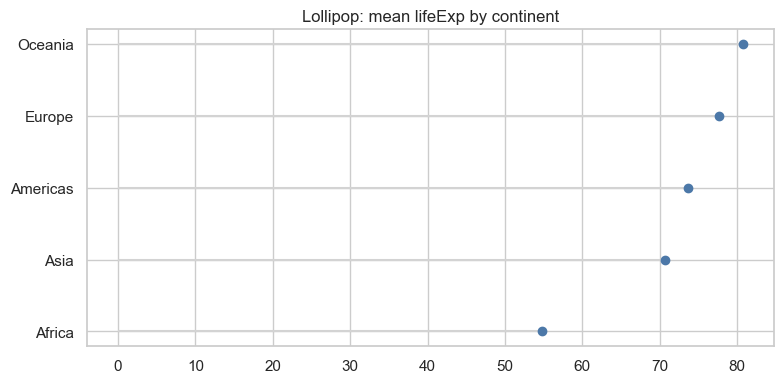

In [2]:
agg = d2007.groupby('continent', as_index=False)['lifeExp'].mean().sort_values('lifeExp')
plt.figure(figsize=(8,4))
plt.hlines(y=agg['continent'], xmin=0, xmax=agg['lifeExp'], color='lightgray')
plt.plot(agg['lifeExp'], agg['continent'], 'o', color='#4C78A8')
plt.title('Lollipop: mean lifeExp by continent')
plt.tight_layout(); plt.show()

## 2) Slope chart (1997 vs 2007)

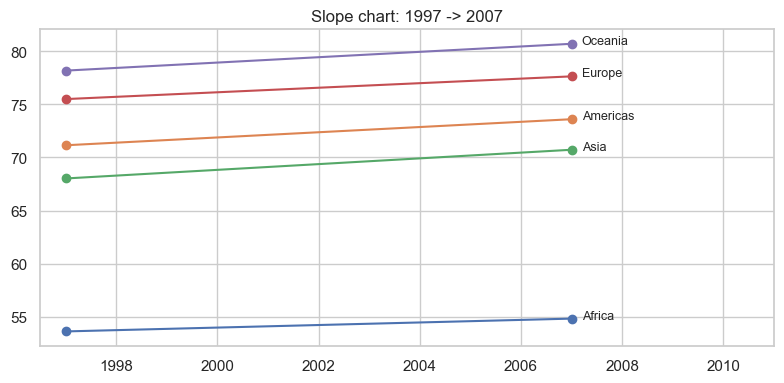

In [3]:
a = df[df['year'].isin([1997,2007])].groupby(['continent','year'],as_index=False)['lifeExp'].mean()
p = a.pivot(index='continent', columns='year', values='lifeExp')
plt.figure(figsize=(8,4))
for c in p.index:
    plt.plot([1997,2007], [p.loc[c,1997], p.loc[c,2007]], marker='o')
    plt.text(2007.2, p.loc[c,2007], c, fontsize=9)
plt.title('Slope chart: 1997 -> 2007')
plt.xlim(1996.5, 2011)
plt.tight_layout(); plt.show()

## 3) Dumbbell chart

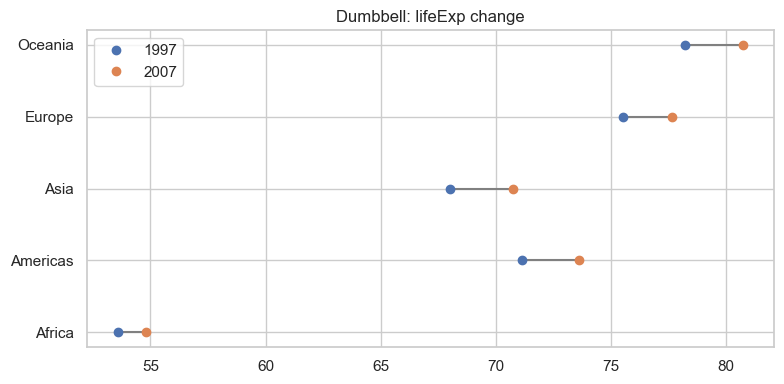

In [4]:
x = a[a['year']==1997].set_index('continent')['lifeExp']
y = a[a['year']==2007].set_index('continent')['lifeExp']
continents = x.index
plt.figure(figsize=(8,4))
plt.hlines(continents, x, y, color='gray')
plt.plot(x, continents, 'o', label='1997')
plt.plot(y, continents, 'o', label='2007')
plt.legend(); plt.title('Dumbbell: lifeExp change')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.